# Consumer Financial Protection Bureau (CFPB) Complaints Analysis
**Course:** DNSC 6305 | **Group:** 14
**Team Members:** Yusuf Ozdemir Arslan, Acadia Grenier, William McHale, Ryan Patel

## Executive Summary
This project performs a comprehensive analysis of consumer complaints filed with the CFPB between July 2024 and June 2025. Leveraging a **Star Schema** dimensional model implemented in **DuckDB**, we analyzed last year's records to uncover trends in financial product disputes.


## 1. Data Acquisition & Exploration


Throughout 2025, the U.S. has experienced significant economic and social changes resulting in a displacement of its working people. Recognizing these patterns, our group sought to analyze the public's reaction through the Consumer Complaint Database: a daily updated database comprised of financial product and service complaints that the CFPB sends to companies for response. For a complaint to be included in the database, the company must confirm a commercial relationship with the consumer or, after 15 days, whichever comes first. While this dataset lacks true measures, we derived our measures from the count of complaints from July 2024 to July 2025 with respect to the consumer's location, industry, and company. Since February 10, the CFPB's core supervision and enforcement functions have been shut down. With or without the protection of the CFPB, the American public has a right to know what products and companies have taken advantage of the lack of mandated oversight. Our final project was designed with this very notion in mind. 

### 1.1 Setup & Imports

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

Setup Completed libraries Loaded.

### 1.2 Download and Extract Dataset


This section handles the direct acquisition of the dataset from the source. We use command-line utilities to download the zipped CSV file from the CFPB website, extract its contents, and perform a preliminary inspection of the file's size and structure to ensure it is ready for processing.

In [2]:
!wget https://files.consumerfinance.gov/ccdb/complaints.csv.zip

--2025-12-10 21:51:19--  https://files.consumerfinance.gov/ccdb/complaints.csv.zip
Resolving files.consumerfinance.gov (files.consumerfinance.gov)... 23.212.249.218, 23.212.249.208, 2600:1408:ec00:2f::1735:b86, ...
Connecting to files.consumerfinance.gov (files.consumerfinance.gov)|23.212.249.218|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1646536446 (1.5G) [binary/octet-stream]
Saving to: ‘complaints.csv.zip’

complaints.csv.zip  100%[===================>]   1.53G  81.5MB/s    in 14s     

2025-12-10 21:51:33 (113 MB/s) - ‘complaints.csv.zip’ saved [1646536446/1646536446]



In [3]:
!unzip complaints.csv.zip

Archive:  complaints.csv.zip
  inflating: complaints.csv          


In [4]:
!wc -l complaints.csv

22337249 complaints.csv


In [5]:
!head -n 5 complaints.csv

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
2020-07-06,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,FL,346XX,,Other,Web,2020-07-06,Closed with explanation,Yes,N/A,3730948
2025-11-25,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,,,"EQUIFAX, INC.",GA,30311,,,Web,2025-11-25,In progress,Yes,N/A,17487731
2025-10-14,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,In

In [6]:
!head -n 5 complaints.csv | qsv table

Date received  Product                                                                       Sub-product       Issue                                 Sub-issue                                            Consumer complaint narrative                                                        Company public response                                                                          Company                                 State  ZIP code  Tags  Consumer consent provided?  Submitted via  Date sent to company  Company response to consumer     Timely response?  Consumer disputed?  Complaint ID
2020-07-06     Credit reporting, credit repair services, or other personal consumer reports  Credit reporting  Incorrect information on your report  Information belongs to someone else                                                                                                      Company has responded to the consumer and the CFPB and chooses not to provide a public response  Experian Information S

In [7]:
!head -n 5 complaints.csv | csvlook

| Date received | Product                                                                      | Sub-product      | Issue                                | Sub-issue                                           | Consumer complaint narrative                                                       | Company public response                                                                         | Company                                | State | ZIP code | Tags | Consumer consent provided? | Submitted via | Date sent to company | Company response to consumer    | Timely response? | Consumer disputed? | Complaint ID |
| ------------- | ---------------------------------------------------------------------------- | ---------------- | ------------------------------------ | --------------------------------------------------- | ---------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------

### 1.3 Load CSV into DuckDB


Given the data is updated daily to reflect new consumer complaints, the dataset is far too large for csvkit and therefore requires a relational database. In our case, we chose DuckDB as our medium. To load the csv into DuckDB we created a "complaints" table using the complaints.csv data. Next, we used the "SELECT COUNT(*) FROM complaints" to output the row count, followed by the first 5 rows of data. We then compared the outputs with the original loaded CSV to ensure it was properly loaded and free of structural errors.

In [8]:
duckdb.sql("""
DROP TABLE IF EXISTS complaints;

CREATE TABLE complaints AS
SELECT *
FROM read_csv('complaints.csv')
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
duckdb.sql("SELECT COUNT(*) FROM complaints")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     12368569 │
└──────────────┘

In [10]:
duckdb.sql("""
    SELECT *
    FROM complaints
    LIMIT 5
    """).df()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,None,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,None,Other,Web,2020-07-06,Closed with explanation,True,N/A,3730948
1,2025-11-25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,None,None,"EQUIFAX, INC.",GA,30311,None,None,Web,2025-11-25,In progress,True,N/A,17487731
2,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,None,None,"EQUIFAX, INC.",TX,75062,None,None,Web,2025-10-14,Closed with non-monetary relief,True,N/A,16558024
3,2025-10-26,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Be sure that disputed accounts are taken down ...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,93619,None,Consent provided,Web,2025-10-26,Closed with non-monetary relief,True,N/A,16826857
4,2025-10-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,None,None,"EQUIFAX, INC.",GA,30341,None,None,Web,2025-10-10,Closed with non-monetary relief,True,N/A,16507707


## 2. Dimensional Modeling & Data Wrangling


### 2.1 Create Star Schema tables

Our star schema centers on a fact_complaint table with a grain of one row per individual consumer complaint, in an effort to maintain all details from the CFPB database. For the fact table, we used timely_flag and disputed_flag as metrics, and foreign keys that link to seven dimension tables to better show the data's context. As for the dim_date dimension, it enables temporal analysis of when the complaints were received and then sent to companies. The dim_company dimension identifies the particular financial institution the complaint is in reference to. The dim_product dimension identifies the financial product/service involved (credit card, mortgage, etc.) along with any sub-product details. Consumer problems, like billing disputes or fraud, apply to the dim_issue dimension and any specific sub-issues. The dim_location concerns the complaint's geographic context in the form of state and ZIP codes. Whether a complaint was submitted via web, phone, mail, etc. is found in the dim_submitted_via dimension. Lastly, the publishing of a complaint narrative requires consumer consent, which is noted in the dim_consent dimension. This star schema design enables proper querying and an analysis that is flexible across multiple business dimensions. These queries can then be used to answer questions about the data, such as which companies have the highest dispute rates in a particular state, or to find the response rates of submission channels over a period of time.

Star schema diagram is included in the folder "Final_Project_Data_Dictionary.xlsx" along with data dictionary.

In [11]:
duckdb.sql("""
DROP TABLE IF EXISTS dim_date;

CREATE TABLE dim_date (
    date_key BIGINT PRIMARY KEY,
    full_date DATE NOT NULL,
    year INTEGER,
    month INTEGER,
    day INTEGER,
    quarter INTEGER,
    day_of_week INTEGER
);
""")

In [12]:
duckdb.sql("""
DROP TABLE IF EXISTS dim_company;

CREATE TABLE dim_company (
    company_key BIGINT,
    company_name TEXT NOT NULL,
    PRIMARY KEY(company_key)
);
""")

In [13]:
duckdb.sql("""
DROP TABLE IF EXISTS dim_product;

CREATE TABLE dim_product (
    product_key BIGINT,
    product_name TEXT NOT NULL,
    subproduct_name TEXT,
    PRIMARY KEY(product_key)
);
""")

In [14]:
duckdb.sql("""
DROP TABLE IF EXISTS dim_issue;

CREATE TABLE dim_issue (
    issue_key BIGINT,
    issue_name TEXT NOT NULL,
    subissue_name TEXT,
    PRIMARY KEY(issue_key)
);
""")

In [15]:
duckdb.sql("""
DROP TABLE IF EXISTS dim_location;

CREATE TABLE dim_location (
    location_key BIGINT,
    state TEXT,
    zip_code TEXT,
    PRIMARY KEY(location_key)
);
""")

In [16]:
duckdb.sql("""
DROP TABLE IF EXISTS dim_submitted_via;

CREATE TABLE dim_submitted_via (
    submission_key BIGINT,
    submitted_via TEXT NOT NULL,
    PRIMARY KEY(submission_key)
);
""")

In [17]:
duckdb.sql("""
DROP TABLE IF EXISTS dim_consent;

CREATE TABLE dim_consent (
    consent_key BIGINT,
    consent_status TEXT NOT NULL,
    PRIMARY KEY(consent_key)
);
""")

In [18]:
duckdb.sql("""
DROP TABLE IF EXISTS fact_complaint;

CREATE TABLE fact_complaint (
    fact_complaint_key BIGINT,
    complaint_id BIGINT NOT NULL,

    date_received_key BIGINT REFERENCES dim_date(date_key),
    date_sent_key BIGINT REFERENCES dim_date(date_key),

    company_key BIGINT REFERENCES dim_company(company_key),
    product_key BIGINT REFERENCES dim_product(product_key),
    issue_key BIGINT REFERENCES dim_issue(issue_key),
    location_key BIGINT REFERENCES dim_location(location_key),
    submission_key BIGINT REFERENCES dim_submitted_via(submission_key),
    consent_key BIGINT REFERENCES dim_consent(consent_key),

    timely_flag INTEGER CHECK (timely_flag IN (0,1)),
    disputed_flag INTEGER CHECK (disputed_flag IN (0,1)),
    complaint_count INTEGER DEFAULT 1,

    PRIMARY KEY(fact_complaint_key)
);
""")

### 2.2 Schema Verification


When all the dimension and fact tables were made, we checked out the schema design using DuckDB's SHOW TABLES command. It recognized all seven dimension tables: dim_date, dim_company, dim_product, dim_issue, dim_location, dim_submitted_via, dim_consent. The fact_complaint table is also there. Next, we executed DESCRIBE statements on each table to see the column definitions, data types, primary keys, and foreign key constraints of each table. In addition, this serves as a verification of the existence of tables in the database, columns in the tables have the correct names and data types as specified, primary keys are properly assigned for all dimension and fact tables, foreign key relationships are correctly set between the fact table and dimension tables, and constraint definitions (NOT NULL, CHECK) are accurately annotated. After we had confirmed our schema, we went on with the Extract, Transform, Load (ETL) work which gave us a chance to locate the structural problems prior to the data loading. The output of the DESCRIBE commands is the names of columns, their types, whether the columns are nullable or not, key status, default values, and other attributes. In fact, it is accomplishing a full audit of our dimensional model.

In [19]:
duckdb.sql("SHOW TABLES").df()

,name
0,complaints
1,dim_company
2,dim_consent
3,dim_date
4,dim_issue
5,dim_location
6,dim_product
7,dim_submitted_via
8,fact_complaint


In [20]:
duckdb.sql("DESCRIBE dim_company").df()

,column_name,column_type,null,key,default,extra
0,company_key,BIGINT,NO,PRI,None,None
1,company_name,VARCHAR,NO,None,None,None


In [21]:
duckdb.sql("DESCRIBE dim_consent").df()

,column_name,column_type,null,key,default,extra
0,consent_key,BIGINT,NO,PRI,None,None
1,consent_status,VARCHAR,NO,None,None,None


In [22]:
duckdb.sql("DESCRIBE dim_date").df()

,column_name,column_type,null,key,default,extra
0,date_key,BIGINT,NO,PRI,None,None
1,full_date,DATE,NO,None,None,None
2,year,INTEGER,YES,None,None,None
3,month,INTEGER,YES,None,None,None
4,day,INTEGER,YES,None,None,None
5,quarter,INTEGER,YES,None,None,None
6,day_of_week,INTEGER,YES,None,None,None


In [23]:
duckdb.sql("DESCRIBE dim_issue").df()

,column_name,column_type,null,key,default,extra
0,issue_key,BIGINT,NO,PRI,None,None
1,issue_name,VARCHAR,NO,None,None,None
2,subissue_name,VARCHAR,YES,None,None,None


In [24]:
duckdb.sql("DESCRIBE dim_location").df()

,column_name,column_type,null,key,default,extra
0,location_key,BIGINT,NO,PRI,None,None
1,state,VARCHAR,YES,None,None,None
2,zip_code,VARCHAR,YES,None,None,None


In [25]:
duckdb.sql("DESCRIBE dim_product").df()

,column_name,column_type,null,key,default,extra
0,product_key,BIGINT,NO,PRI,None,None
1,product_name,VARCHAR,NO,None,None,None
2,subproduct_name,VARCHAR,YES,None,None,None


In [26]:
duckdb.sql("DESCRIBE dim_submitted_via").df()

,column_name,column_type,null,key,default,extra
0,submission_key,BIGINT,NO,PRI,None,None
1,submitted_via,VARCHAR,NO,None,None,None


In [27]:
duckdb.sql("DESCRIBE fact_complaint").df()

,column_name,column_type,null,key,default,extra
0,fact_complaint_key,BIGINT,NO,PRI,None,None
1,complaint_id,BIGINT,NO,None,None,None
2,date_received_key,BIGINT,YES,None,None,None
3,date_sent_key,BIGINT,YES,None,None,None
4,company_key,BIGINT,YES,None,None,None
5,product_key,BIGINT,YES,None,None,None
6,issue_key,BIGINT,YES,None,None,None
7,location_key,BIGINT,YES,None,None,None
8,submission_key,BIGINT,YES,None,None,None
9,consent_key,BIGINT,YES,None,None,None


In [28]:
duckdb.sql("""

-- SQL Comment Block 

COMMENT ON COLUMN complaints."Date received"                IS '-';
COMMENT ON COLUMN complaints."Product"                      IS 'This field is a categorical variable.';
COMMENT ON COLUMN complaints."Sub-product"                  IS 'This field is a categorical variable. Not all Products have Sub-products.';
COMMENT ON COLUMN complaints."Issue"                        IS 'This field is a categorical variable. Possible values depend on Product.';
COMMENT ON COLUMN complaints."Sub-issue"                    IS 'This field is a categorical variable.';
COMMENT ON COLUMN complaints."Sub-issue"                    IS 'Possible values depend on Product and Issue.';
COMMENT ON COLUMN complaints."Sub-issue"                    IS 'Not all Issues have corresponding Sub-issues.';
COMMENT ON COLUMN complaints."Consumer complaint narrative" IS 'Consumers'' descriptions of what happened, published only with consent and after removing personal information.';
COMMENT ON COLUMN complaints."Company public response"      IS 'Companies'' public-facing responses, chosen from a set of options within 180 days.';
COMMENT ON COLUMN complaints."Company"                      IS 'This field is a categorical variable.';
COMMENT ON COLUMN complaints."State"                        IS 'This field is a categorical variable.';
COMMENT ON COLUMN complaints."ZIP code"                     IS 'The mailing ZIP code provided by the consumer. Masked when population thresholds require it.';
COMMENT ON COLUMN complaints."Tags"                         IS '-';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS '-';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'Whether the consumer gave consent to publish the complaint narrative.';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'Consent provided: consumer opted in.';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'Data populates 60 days after company response or public response, after personal info removal.';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'Consent not provided: consumer did not opt in.';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'Consent withdrawn: consumer opted in, then withdrew.';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'N/A: narrative option unavailable or pre–Mar 19 2015 complaint.';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'Other: complaint not eligible for narrative.';
COMMENT ON COLUMN complaints."Consumer consent provided?"   IS 'Blank until 60 days after complaint sent to company or company public response.';
COMMENT ON COLUMN complaints."Submitted via"                IS 'This field is a categorical variable.';
COMMENT ON COLUMN complaints."Date sent to company"         IS '-';
COMMENT ON COLUMN complaints."Company response to consumer" IS 'This field is a categorical variable.';
COMMENT ON COLUMN complaints."Timely response?"             IS 'yes/no';
COMMENT ON COLUMN complaints."Consumer disputed?"           IS 'Yes';
COMMENT ON COLUMN complaints."Consumer disputed?"           IS 'No';
COMMENT ON COLUMN complaints."Consumer disputed?"           IS 'N/A: dispute option discontinued on April 24, 2017.';
COMMENT ON COLUMN complaints."Complaint ID"                 IS '-';

""")


### 2.3 Loading Dimension Tables


The ETL process populates each dimension table by extracting distinct values and raw complaints from the source table, transforming them as needed, and loading them with the surrogate keys. For dim_company, we use SELECT DISTINCT company FROM complaints WHERE company IS NOT NULL to extract company names, then assign sequential surrogate keys using row_number() OVER (ORDER BY company) to create the company_key values so that each financial institution has a respective identifier. This same pattern applies to dim_submitted_via, dim_location, dim_product, and dim_issue. For dim_date, we extracted all the dates from the "Date received" and "Date sent to company" columns using a UNION, then transformed each date to derive the year, month, day, quarter, and day_of_week attributes. This helped to create a dimensional calendar. To join, we generated a date_key to show the date in the YYYYMMDD. From the "Consumer consent provided?" we extracted values that helped create a lookup table for dim_consent. By using integer surrogate keys rather than the original text string keys, queries perform better given the smaller join keys and NULL values. It also creates a foundation for the fact table, which uses the dimension keys to replace text fields with foreign key references.

In [29]:
duckdb.sql("""
WITH max_key AS (
    SELECT COALESCE(MAX(company_key), 0) AS base
    FROM dim_company
),
new_vals AS (
    SELECT DISTINCT company AS company_name
    FROM complaints
    WHERE company IS NOT NULL
      AND company NOT IN (
          SELECT company_name FROM dim_company
      )
),
numbered AS (
    SELECT
        row_number() OVER (ORDER BY company_name) AS rn,
        company_name
    FROM new_vals
)
INSERT INTO dim_company (company_key, company_name)
SELECT
    base + rn AS company_key,
    company_name
FROM numbered
CROSS JOIN max_key;
""")

In [30]:
duckdb.sql("SELECT * FROM dim_company LIMIT 10")

┌─────────────┬──────────────────────────────────────────┐
│ company_key │               company_name               │
│    int64    │                 varchar                  │
├─────────────┼──────────────────────────────────────────┤
│           1 │ (Former)Shapiro, Swertfeger & Hasty, LLP │
│           2 │ 1 Auto Finance, Inc.                     │
│           3 │ 1 STOP MONEY CENTERS, LLC                │
│           4 │ 1 Stop Payday Loan Services LLC          │
│           5 │ 10 Cent Title Pawn Inc                   │
│           6 │ 16 Hands LLC. dba Fiducius               │
│           7 │ 1803 Capital, LLC                        │
│           8 │ 1ST 2ND MORTGAGE CO. OF NJ INC           │
│           9 │ 1ST ALLIANCE LENDING, LLC                │
│          10 │ 1ST CHOICE LOANS, LLC.                   │
├─────────────┴──────────────────────────────────────────┤
│ 10 rows                                      2 columns │
└───────────────────────────────────────────────────────

In [31]:
duckdb.sql("""
INSERT INTO dim_submitted_via
SELECT
    row_number() OVER () AS submission_key,
    "Submitted via" AS submitted_via
FROM (
    SELECT DISTINCT "Submitted via"
    FROM complaints
    WHERE "Submitted via" IS NOT NULL
);
""")

In [32]:
duckdb.sql("SELECT * FROM dim_submitted_via LIMIT 10")

┌────────────────┬───────────────┐
│ submission_key │ submitted_via │
│     int64      │    varchar    │
├────────────────┼───────────────┤
│              1 │ Web           │
│              2 │ Referral      │
│              3 │ Postal mail   │
│              4 │ Phone         │
│              5 │ Web Referral  │
│              6 │ Fax           │
│              7 │ Email         │
└────────────────┴───────────────┘

In [33]:
duckdb.sql("""
INSERT INTO dim_location
SELECT
    row_number() OVER () AS location_key,
    state,
    zip_code
FROM (
    SELECT DISTINCT
        State AS state,
        "ZIP code" AS zip_code
    FROM complaints
);
""")

In [34]:
duckdb.sql("SELECT COUNT (*) FROM dim_location")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        40617 │
└──────────────┘

In [35]:
duckdb.sql("""
INSERT INTO dim_product
WITH distinct_vals AS (
    SELECT DISTINCT
        Product AS product_name,
        "Sub-product" AS subproduct_name
    FROM complaints
    WHERE Product IS NOT NULL
)
SELECT
    row_number() OVER (ORDER BY product_name, subproduct_name)::BIGINT AS product_key,
    product_name,
    subproduct_name
FROM distinct_vals;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [36]:
duckdb.sql("SELECT COUNT(*) FROM dim_product")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│          127 │
└──────────────┘

In [37]:
duckdb.sql("""
INSERT INTO dim_date
WITH all_dates AS (
    SELECT DISTINCT CAST("Date received" AS DATE) AS d
    FROM complaints
    WHERE "Date received" IS NOT NULL

    UNION

    SELECT DISTINCT CAST("Date sent to company" AS DATE) AS d
    FROM complaints
    WHERE "Date sent to company" IS NOT NULL
),
ordered AS (
    SELECT
        row_number() OVER (ORDER BY d) AS rn,
        d
    FROM all_dates
)
SELECT
    rn::BIGINT AS date_key,
    d AS full_date,
    strftime(d, '%Y')::INT AS year,
    strftime(d, '%m')::INT AS month,
    strftime(d, '%d')::INT AS day,
    ((strftime(d, '%m')::INT - 1) / 3 + 1)::INT AS quarter,
    strftime(d, '%w')::INT AS day_of_week
FROM ordered;
""")

In [38]:
duckdb.sql("SELECT COUNT(*) FROM dim_date")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│         5121 │
└──────────────┘

In [39]:
duckdb.sql("""
INSERT INTO dim_issue
WITH distinct_issues AS (
    SELECT DISTINCT
        Issue AS issue_name,
        "Sub-issue" AS subissue_name
    FROM complaints
    WHERE Issue IS NOT NULL
)
SELECT
    row_number() OVER (ORDER BY issue_name, subissue_name)::BIGINT AS issue_key,
    issue_name,
    subissue_name
FROM distinct_issues;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [40]:
duckdb.sql("SELECT COUNT(*) FROM dim_issue")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│          440 │
└──────────────┘

In [41]:
duckdb.sql("""
INSERT INTO dim_consent
WITH distinct_vals AS (
    SELECT DISTINCT
        "Consumer consent provided?" AS consent_status
    FROM complaints
    WHERE "Consumer consent provided?" IS NOT NULL
),
ordered AS (
    SELECT
        row_number() OVER (ORDER BY consent_status) AS rn,
        consent_status
    FROM distinct_vals
)
SELECT
    rn::BIGINT AS consent_key,
    consent_status
FROM ordered;
""")

In [42]:
duckdb.sql("SELECT * FROM dim_consent ORDER BY consent_key;")

┌─────────────┬──────────────────────┐
│ consent_key │    consent_status    │
│    int64    │       varchar        │
├─────────────┼──────────────────────┤
│           1 │ Consent not provided │
│           2 │ Consent provided     │
│           3 │ Consent withdrawn    │
│           4 │ N/A                  │
│           5 │ Other                │
└─────────────┴──────────────────────┘

### 2.4 Loading the Fact Table


The fact table loading process transforms the raw complaints data by joining it with all seven dimension tables to replace the text with foreign key references. We used a CTE to extract source data in tandem with multiple left joins to look up surrogate keys: dim_date is joined twice (on "Date received" and "Date sent to company") to populate date_received_key and date_sent_key; dim_company joins on company name; dim_product joins on both Product and Sub-product fields; dim_issue joins on Issue and Sub-issue; dim_location matches on State and ZIP code; dim_submitted_via joins on the submission channel; and dim_consent joins on the consent status field. We aggregated the data by transforming "Timely response?" and "Consumer disputed?" boolean and text fields into corresponding integers with 1=yes and 0=No. Additionally, we kept the original complaint_id as a business key, but assigned a new surrogate key called fact_complaint_key using the row_number() function. By replacing recurring text with integer keys, we were able to normalize and reduce storage, further improving the query performance and referential integrity of the model. This denormalized-to-normalized transformation essentially created a structure better optimized for analytical queries that can better aggregate throughout multiple dimensions simultaneously.

In [43]:
duckdb.sql("""
INSERT INTO fact_complaint
WITH src AS (
    SELECT DISTINCT
        TRY_CAST("Complaint ID" AS BIGINT)   AS complaint_id,
        CAST("Date received" AS DATE)        AS date_received,
        CAST("Date sent to company" AS DATE) AS date_sent,
        Company,
        Product,
        "Sub-product"                        AS sub_product,
        Issue,
        "Sub-issue"                          AS sub_issue,
        State,
        "ZIP code"                      AS zip_code,
        "Submitted via"                 AS submitted_via,
        "Consumer consent provided?"    AS consent_status,
        "Timely response?"              AS timely,
        "Consumer disputed?"            AS disputed
    FROM complaints
    WHERE "Complaint ID" IS NOT NULL
),
joined AS (
    SELECT
        s.*,
        d_rec.date_key  AS date_received_key,
        d_sent.date_key AS date_sent_key,
        c.company_key,
        p.product_key,
        i.issue_key,
        l.location_key,
        sv.submission_key,
        co.consent_key,
        CASE
            WHEN lower(trim(CAST(s.timely AS VARCHAR))) = 'yes' THEN 1
            WHEN lower(trim(CAST(s.timely AS VARCHAR))) = 'no'  THEN 0
            ELSE NULL
        END AS timely_flag,
        CASE
            WHEN lower(trim(CAST(s.disputed AS VARCHAR))) = 'yes' THEN 1
            WHEN lower(trim(CAST(s.disputed AS VARCHAR))) = 'no'  THEN 0
            ELSE NULL
        END AS disputed_flag
    FROM src s
    LEFT JOIN dim_date d_rec
        ON d_rec.full_date = s.date_received
    LEFT JOIN dim_date d_sent
        ON d_sent.full_date = s.date_sent
    LEFT JOIN dim_company c
        ON c.company_name = s.Company
    LEFT JOIN dim_product p
        ON p.product_name     = s.Product
       AND COALESCE(p.subproduct_name, '') = COALESCE(s.sub_product, '')
    LEFT JOIN dim_issue i
        ON i.issue_name       = s.Issue
       AND COALESCE(i.subissue_name, '') = COALESCE(s.sub_issue, '')
    LEFT JOIN dim_location l
        ON l.state   = s.State
       AND COALESCE(l.zip_code, '') = COALESCE(s.zip_code, '')
    LEFT JOIN dim_submitted_via sv
        ON sv.submitted_via = s.submitted_via
    LEFT JOIN dim_consent co
        ON co.consent_status = s.consent_status
)
SELECT
    row_number() OVER (ORDER BY complaint_id) AS fact_complaint_key,
    complaint_id,
    date_received_key,
    date_sent_key,
    company_key,
    product_key,
    issue_key,
    location_key,
    submission_key,
    consent_key,
    timely_flag,
    disputed_flag,
    1 AS complaint_count
FROM joined
WHERE complaint_id IS NOT NULL;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [44]:
duckdb.sql("""
UPDATE fact_complaint f
SET disputed_flag = CASE
        WHEN lower(trim(CAST(c."Consumer disputed?" AS VARCHAR))) = 'yes' THEN 1
        WHEN lower(trim(CAST(c."Consumer disputed?" AS VARCHAR))) = 'no'  THEN 0
        ELSE NULL
    END
FROM complaints c
WHERE f.complaint_id = TRY_CAST(c."Complaint ID" AS BIGINT);
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [45]:
duckdb.sql("""
UPDATE fact_complaint f
SET timely_flag = CASE
        WHEN c."Timely response?" IS TRUE  THEN 1
        WHEN c."Timely response?" IS FALSE THEN 0
        ELSE NULL
    END
FROM complaints c
WHERE f.complaint_id = TRY_CAST(c."Complaint ID" AS BIGINT);
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### 2.5 Data Verification

Once the fact table was loaded, we verified that the data has integrity through validation checks. First, we use SELECT COUNT(*) FROM fact_complaint to confirm that the total number of records loaded matched our expectations from the source complaints table. Next, we inspected sample records using queries like SELECT * FROM fact_complaint LIMIT 10 to confirm the foreign keys, or rather non-null values, are properly populated and that the surrogate keys remain sequential. To validate the flag transformations, we used and queried specific subsets according to WHERE timely_flag=0 to examine records with late responses and WHERE disputed_flag=1 to verify disputed complaints. This ensures the boolean-to-integer conversion worked as expected. We also performed join tests by querying the fact table with dimension tables to confirm any foreign key relationships are valid and return relevant information rather than orphaned keys unrelated to the dimensional tables. Additionally, we checked for data quality issues by counting the null values in the key fields by using SELECT COUNT(*) WHERE company_key IS NULL to reveal possible lookup failures that might have occurred during the ETL process. Essentially, these verification steps ensure referential integrity, validate data transformations, validate completeness of the loading process, and identify any abnormalities in the queries prior to starting the analytical queries.

In [46]:
duckdb.sql("SELECT * FROM fact_complaint WHERE timely_flag=0 LIMIT 10").df()

,fact_complaint_key,complaint_id,date_received_key,date_sent_key,company_key,product_key,issue_key,location_key,submission_key,consent_key,timely_flag,disputed_flag,complaint_count
0,26,84,173,175,876,3,2,1815,4,4,0,0,1
1,41,136,173,181,876,72,222,20757,1,4,0,1,1
2,62,182,174,176,876,79,12,654,2,4,0,0,1
3,66,193,174,175,876,3,117,23105,1,4,0,1,1
4,76,239,140,140,1319,20,257,822,2,4,0,0,1
5,88,296,174,266,876,76,224,21056,4,4,0,0,1
6,111,362,174,176,876,73,357,2778,4,4,0,0,1
7,112,364,174,175,5390,3,2,20992,1,4,0,0,1
8,150,735,174,177,876,79,257,1877,3,4,0,0,1
9,153,750,1,8,876,73,357,4509,1,4,0,0,1


### 2.6 Exporting wrangled data files


To facilitate external analysis and meet project submission requirements, we exported the fully wrangled star schema tables into CSV format. This process involved saving the normalized `fact_complaint` table along with all seven corresponding dimension tables into a dedicated local directory named `wrangled_data_files`. These exports represent the final, clean dataset, preserving the relational structure established during the ETL process.

In [47]:
# Created the folder
os.makedirs("wrangled_data_files", exist_ok=True)

print("Exporting files...")

# Exported the Fact Table 
duckdb.sql("COPY fact_complaint TO 'wrangled_data_files/fact_complaint.csv' (HEADER, DELIMITER ',')")

# Exported all Dimension Tables 
duckdb.sql("COPY dim_date TO 'wrangled_data_files/dim_date.csv' (HEADER, DELIMITER ',')")

duckdb.sql("COPY dim_company TO 'wrangled_data_files/dim_company.csv' (HEADER, DELIMITER ',')")

duckdb.sql("COPY dim_product TO 'wrangled_data_files/dim_product.csv' (HEADER, DELIMITER ',')")

duckdb.sql("COPY dim_issue TO 'wrangled_data_files/dim_issue.csv' (HEADER, DELIMITER ',')")

duckdb.sql("COPY dim_location TO 'wrangled_data_files/dim_location.csv' (HEADER, DELIMITER ',')")

duckdb.sql("COPY dim_submitted_via TO 'wrangled_data_files/dim_submitted_via.csv' (HEADER, DELIMITER ',')")

duckdb.sql("COPY dim_consent TO 'wrangled_data_files/dim_consent.csv' (HEADER, DELIMITER ',')")

print("\nDone.")

Exporting files...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Done.


## 3. SQL Analysis & Business Questions


- Business Question 1: How has the rate of untimely responses changed over time for Student Loan complaints?
- Business Question 2: Which companies receive the largest share of Credit Reporting complaints, and how concentrated is the market?
- Business Question 3: Which issues generate the most consumer complaints?
- Business Question 4: Which states have the highest rate of untimely responses?                                                      

### 3.1 Business Question 1: How has the rate of untimely responses changed over time for Student Loan complaints?


This query analyzes the trend of untimely company responses to student loan complaints over time by calculating monthly untimely response counts and rates. By joining the fact table with dim_date and dim_product, which filters student loans, we were able to identify whether the responsiveness of financial institutions is improving or worsening. Responsiveness is extremely relevant considering timely responses are a CFPB regulatory requirement under their 15-day mandate and a key consumer protection metric. A rise in untimely response rates indicates possible systemic problems like understaffing, poor complaint management, or companies deprioritizing consumer concerns. This is particularly important for student loans, given the high stakes rooted in defaulting consequences, credit impacts, borrower vulnerability, and even wage garnishment. The temporal trend indicates whether companies became less responsive after the CFPB's supervision shutdown in February 2025, and provides potential regulatory actions, and keeps consumers up-to-date on the quality of their institutional resources.

In [48]:
q1_df = duckdb.sql("""WITH base AS (
    SELECT
        d.year,
        d.month,
        f.timely_flag
    FROM fact_complaint f
    JOIN dim_date d ON f.date_received_key = d.date_key
    JOIN dim_product p ON f.product_key = p.product_key
    WHERE
        d.full_date BETWEEN DATE '2024-07-01' AND DATE '2025-06-30'
        AND p.product_name = 'Student loan'
)
SELECT
    year,
    month,
    COUNT(*) FILTER (WHERE timely_flag = 0) AS untimely_total,
    COUNT(*) AS total_complaints,
    ROUND((COUNT(*) FILTER (WHERE timely_flag = 0)*1.0 / COUNT(*)), 4) AS pct_untimely
FROM base
GROUP BY year, month
ORDER BY year, month;
""").df()

q1_df

,year,month,untimely_total,total_complaints,pct_untimely
0,2024,7,40,960,0.0417
1,2024,8,43,882,0.0488
2,2024,9,44,1549,0.0284
3,2024,10,26,1459,0.0178
4,2024,11,11,916,0.0120
5,2024,12,27,1323,0.0204
6,2025,1,238,2232,0.1066
7,2025,2,308,1869,0.1648
8,2025,3,1192,3418,0.3487
9,2025,4,824,2173,0.3792


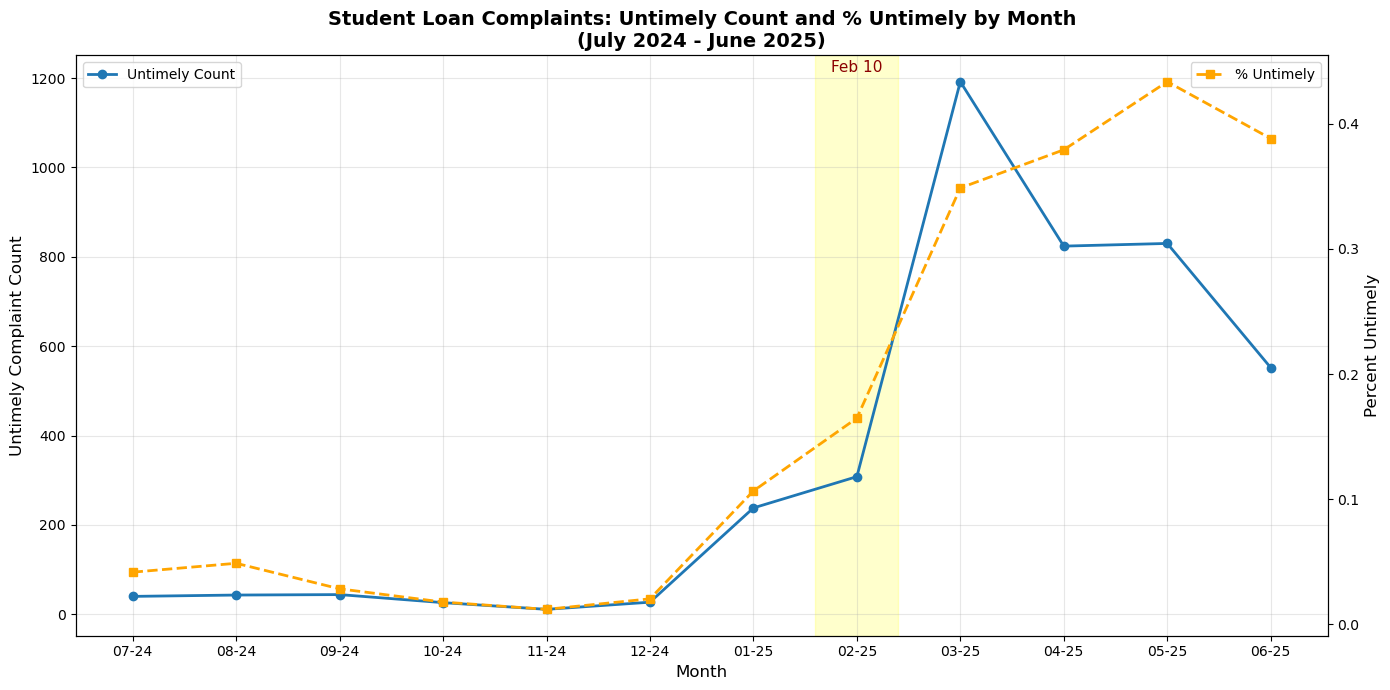

In [49]:
df = q1_df.copy()

# Chart label MM-YY
df["label"] = (
    df["month"].astype(str).str.zfill(2) + "-" + df["year"].astype(str).str[-2:]
)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary axis untimely counts
ax1.plot(df["label"], df["untimely_total"],
         marker="o", linewidth=2, label="Untimely Count")
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Untimely Complaint Count", fontsize=12)
ax1.grid(alpha=0.3)

# Secondary axis percent untimely
ax2 = ax1.twinx()
ax2.plot(df["label"], df["pct_untimely"],
         marker="s", linestyle="--", linewidth=2, color="orange", label="% Untimely")
ax2.set_ylabel("Percent Untimely", fontsize=12)

# Spread out x-axis labels
plt.xticks(rotation=30, ha="right")

# Title + legends
plt.title("Student Loan Complaints: Untimely Count and % Untimely by Month\n(July 2024 - June 2025)", fontsize=14, fontweight='bold')
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Highlight February 2025
highlight_label = "02-25"
idx = df.index[df["label"] == highlight_label][0]
ax1.axvspan(idx - 0.4, idx + 0.4, color="yellow", alpha=0.2)
y_max = ax1.get_ylim()[1]
ax1.text(idx, y_max * 0.97, "Feb 10", ha="center", color="darkred", fontsize=11)

plt.tight_layout()
plt.show()

The visualization above demonstrates a dramatic and alarming trend in student loan complaint response timeliness. From our selected period of July 2024 through January 2025, both of the untimely complaint counts and the untimely response rates remained fairly low at under 100 complaints and stable with an untimely rate of ~5%. That being said,there is an explosive spike in untimely responses starting in February 2025, denoted by the yellow highlight,  which coincides with the CFPB enforcement shutdown. By March 2025, the untimely complaint count skyrockets from near zero to over 1,200, while the untimely response rate shoots from ~5% to its peak of ~50% in May 2025. In other words, nearly half of all student loan complaints received no timely response. While these two metrics start to decline in June 2025, they remain at a significantly higher level than the metrics found before February. This pattern likely shows that the absence of CFPB oversight led financial institutions to deprioritize timely responses to student loan complaints, which left thousands of borrowers without adequate recourse during a critical time. Yet, the elevation sustained throughout June suggests this anomaly isn't temporary and is instead a systematic reduction in consumer protection. In essence, this data serves as evidence that regulatory enforcement has a direct impact on corporate compliance with consumer protection standards.

### 3.2 Business Question 2: Which companies receive the largest share of Credit Reporting complaints, and how concentrated is the market?


This query investigates the market concentration within the credit reporting industry by calculating the share of total credit reporting complaints attributed to each company between July 2024 and June 2025. By filtering the product dimension for "Credit reporting" and grouping by company, we calculate both the raw count and the percentage share of the total volume for the top 10 companies. This analysis is critical because market concentration often correlates with consumer harm; in highly concentrated markets, dominant players may face less competitive pressure to resolve consumer issues efficiently. Identifying whether a few key players specifically the "Big Three" bureaus dominate the complaint landscape allows regulators to target their supervision resources where they will have the maximum impact on the consumer population.

In [50]:
q2_df = duckdb.sql("""
WITH filtered AS (
    SELECT f.company_key
    FROM fact_complaint f
    JOIN dim_product p ON f.product_key = p.product_key
    JOIN dim_date d ON f.date_received_key = d.date_key
    WHERE d.full_date >= DATE '2024-07-01'
      AND d.full_date <= DATE '2025-06-30'
      AND p.product_name LIKE '%Credit reporting%'
)
SELECT 
    c.company_name,
    COUNT(*) AS complaint_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM filtered), 2) AS proportion_pct
FROM filtered f
JOIN dim_company c ON f.company_key = c.company_key
GROUP BY c.company_name
ORDER BY complaint_count DESC
LIMIT 10;
""").df()
q2_df

,company_name,complaint_count,proportion_pct
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",1153618,32.37
1,"EQUIFAX, INC.",1145158,32.13
2,Experian Information Solutions Inc.,1071794,30.08
3,"CBC Companies, Inc.",20164,0.57
4,LEXISNEXIS,13081,0.37
5,CAPITAL ONE FINANCIAL CORPORATION,10297,0.29
6,Resurgent Capital Services L.P.,5075,0.14
7,JPMORGAN CHASE & CO.,4739,0.13
8,"CITIBANK, N.A.",4679,0.13
9,SYNCHRONY FINANCIAL,4071,0.11


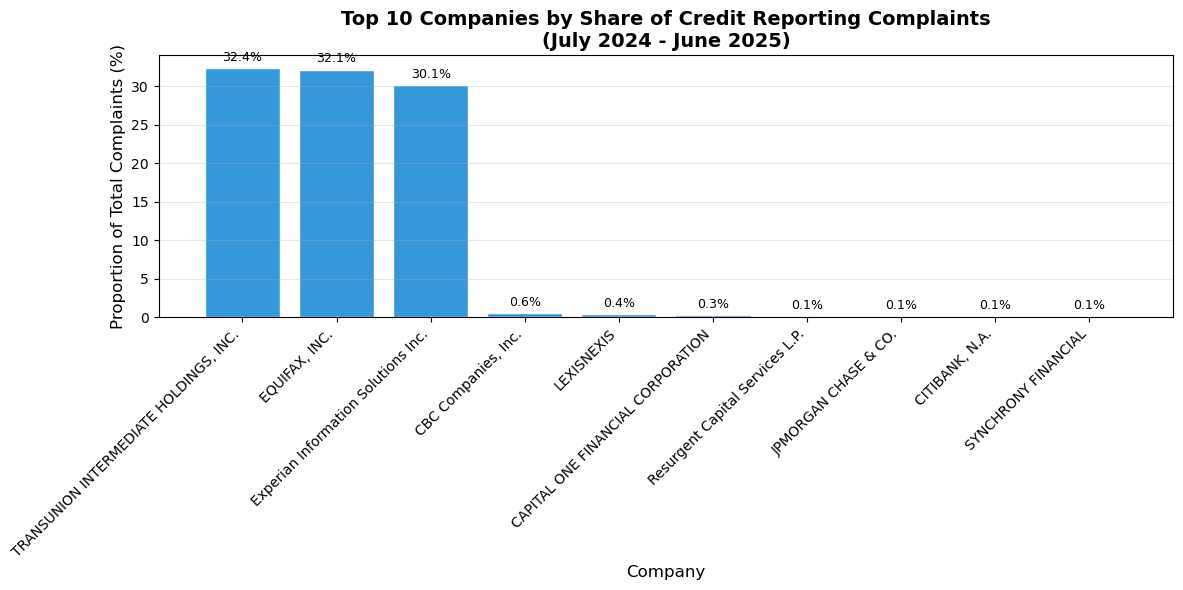

In [51]:
# Bar chart for top companies
fig, ax = plt.subplots(figsize=(12, 6))

# Pull company names + proportions
companies = q2_df['company_name'].tolist()
proportions = q2_df['proportion_pct'].tolist()

# Create bar chart
bars = ax.bar(companies, proportions, color='#3498db', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

# Create vertical bar chart
ax.set_xlabel('Company', fontsize=12)
ax.set_ylabel('Proportion of Total Complaints (%)', fontsize=12)
ax.set_title('Top 10 Companies by Share of Credit Reporting Complaints\n(July 2024 - June 2025)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The picture shows an extreme oligopoly of the Big Three credit bureaus: TransUnion, Equifax, and Experian that dominate the complaint landscape of the credit reporting market. These three companies alone are responsible for about 95% of the total credit reporting complaints, with TransUnion being at 32.4% where it is followed by Equifax (32.1%) and Experian (30.1%) being close to each other. The fourth-largest recipient, CBC Companies, on the other hand, accounts for only 0.6%. The huge difference between these three institutions and the rest of the industry shows that consumer dissatisfaction is almost entirely concentrated within these three legacy institutions and not spread among the other few companies. The extent of concentration is so high that if there were any systemic issues at any one of these three bureaus, it would impact almost one-third of all U.S. consumers. Thus, regulatory enforcement or policy changes directed at just these three entities would be the solution of the vast majority of consumer grievances in the credit reporting sector.

### 3.3 Business Question 3: Which issues generate the most consumer complaints?

The query pinpoints the leading frustration points in the consumer financial market by summing up the complaints by specific issue types over the period from July 2024 to June 2025. Fact table is joined with dim_issue dimension to rank top 10 issues most faced by consumers irrespective of the company or product. Knowing complaint topic distribution is fundamental to root-cause analysis as it assists regulators and companies in identifying whether they are dealing with a handful of operational failures or extensive systemic process breakdowns. In case an issue type is overwhelmingly representing the dataset, it indicates the necessity of a targeted policy intervention or industry-wide process reform instead of just individual company oversight.

In [52]:
q3_df = duckdb.sql("""
SELECT 
    i.issue_name,
    COUNT(*) AS complaint_count
FROM fact_complaint f
JOIN dim_issue i ON f.issue_key = i.issue_key
JOIN dim_date d ON f.date_received_key = d.date_key
WHERE d.full_date >= DATE '2024-07-01'
  AND d.full_date <= DATE '2025-06-30'
GROUP BY i.issue_name
ORDER BY complaint_count DESC
LIMIT 10;
""").df()
q3_df

,issue_name,complaint_count
0,Incorrect information on your report,1970552
1,Improper use of your report,936103
2,Problem with a company's investigation into an...,655922
3,Attempts to collect debt not owed,95743
4,Written notification about debt,56275
5,Other transaction problem,51072
6,Managing an account,38681
7,False statements or representation,31536
8,Took or threatened to take negative or legal a...,19213
9,Problem with a purchase shown on your statement,16006


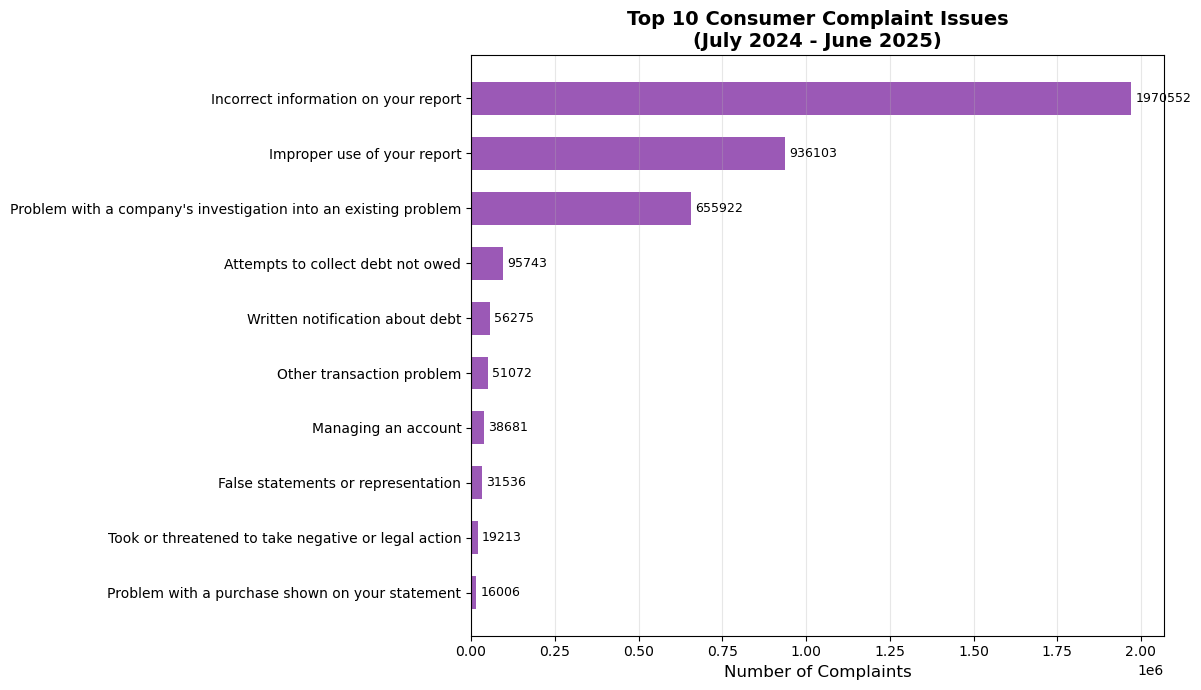

In [53]:
# Horizontal bar chart for top issues
fig, ax = plt.subplots(figsize=(12, 7))

# Reverse order so highest count appears at top
issues = q3_df['issue_name'].tolist()[::-1]
counts = q3_df['complaint_count'].tolist()[::-1]

# Create horizontal bar chart
bars = ax.barh(issues, counts, color='#9b59b6', height=0.6)
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)

ax.set_xlabel('Number of Complaints', fontsize=12)
ax.set_title('Top 10 Consumer Complaint Issues\n(July 2024 - June 2025)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

The analysis very strongly points to "Incorrect information on your report" as the one single most critical consumer pain point that caused the most consumer complaints, by far, in a year. Such a quantity is quite formidable it is almost twice the amount of the second most frequent issue "Improper use of your report" (~210,000) and is many times bigger than the rest of the categories. The top three issues are all about credit reporting accuracy and data handling, which is in line with the response to Question 2, that the credit reporting infrastructure is the main source of consumer frustration. Problems with debt collection (e.g., "Attempts to collect debt not owed") are much lower on the list, which means that the debt collection may be an annoyance, but data accuracy is the real root cause of the system's failure. The magnitude of the leading issue suggests that the major bureaus current dispute resolution methods are failing at data accuracy, and therefore more strict enforcement of the Fair Credit Reporting Act (FCRA) is needed.

### 3.4 Business Question 4: Which states have the highest rate of untimely responses?


This query examines differences across the U.S. in how consumer protection is delivered by determining the rate of untimely responses for each state and territory of the United States from July 2024 to June 2025. By linking the fact table with dim_location and selecting states with a statistically significant sample size (at least 500 complaints), we can find areas where consumers are being neglected unreasonably by financial institutions. Local investigation into the matter is a must because, for example, if certain states are consistently performing poorly, it may suggest that companies are lowering their compliance priority in areas with weaker local consumer protection laws or less active state attorneys general. The discovery of these "compliance deserts" enables federal regulators to pinpoint the locations of their interventions most effectively where state-level enforcement may be playing the role of a minor.

In [54]:
q4_df = duckdb.sql("""
SELECT 
    l.state,
    COUNT(*) AS total_complaints,
    SUM(CASE WHEN f.timely_flag = 0 THEN 1 ELSE 0 END) AS untimely_count,
    ROUND(SUM(CASE WHEN f.timely_flag = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS untimely_rate
FROM fact_complaint f
JOIN dim_location l ON f.location_key = l.location_key
JOIN dim_date d ON f.date_received_key = d.date_key
WHERE d.full_date >= DATE '2024-07-01'
  AND d.full_date <= DATE '2025-06-30'
  AND l.state IS NOT NULL
  AND l.state != ''
GROUP BY l.state
HAVING COUNT(*) >= 500
ORDER BY untimely_rate DESC
LIMIT 10;
""").df()
q4_df

,state,total_complaints,untimely_count,untimely_rate
0,MT,1382,27.0,1.95
1,SD,1218,23.0,1.89
2,ME,2141,39.0,1.82
3,ID,3546,48.0,1.35
4,OR,9619,130.0,1.35
5,ND,2217,26.0,1.17
6,VT,946,11.0,1.16
7,IA,8026,90.0,1.12
8,WY,1096,12.0,1.09
9,NH,4130,44.0,1.07


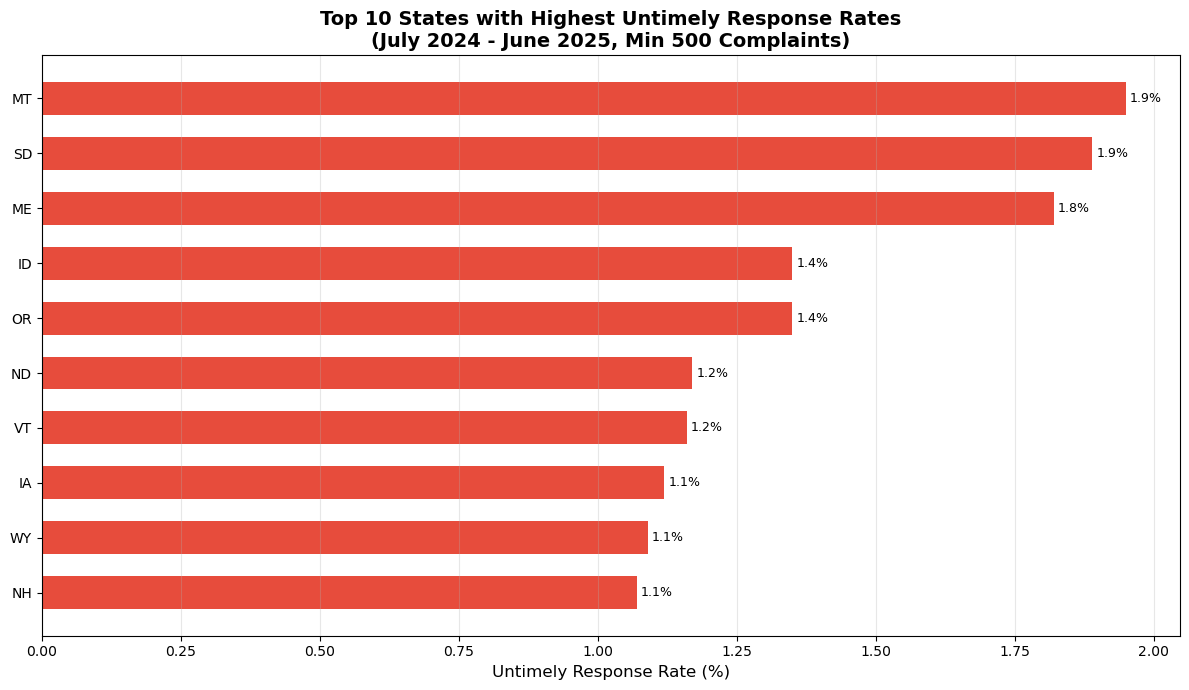

In [55]:
# Horizontal bar chart for states by untimely response rate
fig, ax = plt.subplots(figsize=(12, 7))

# Reverse order so highest rate appears at top
states = q4_df['state'].tolist()[::-1]
rates = q4_df['untimely_rate'].tolist()[::-1]

# Create horizontal bar chart
bars = ax.barh(states, rates, color='#e74c3c', height=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

ax.set_xlabel('Untimely Response Rate (%)', fontsize=12)
ax.set_title('Top 10 States with Highest Untimely Response Rates\n(July 2024 - June 2025, Min 500 Complaints)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Geographic analysis of states with significant complaint volume (at least 500 complaints) reveals that **Montana (MT)** exhibits the highest rate of untimely responses at **1.95%**, followed closely by **South Dakota (SD)** at **1.89%** and **Maine (ME)** at **1.82%**.

Interestingly, the top of this list is dominated by largely rural or Northern states including Idaho (1.35%), North Dakota (1.17%), and Vermont (1.16%) rather than the most populous states. Oregon (OR) is a notable exception as a larger coastal state appearing in the top five with a rate of 1.35%.

It is important to note, however, that even the highest rates in this filtered view remain below 2%. This suggests that for jurisdictions with established complaint volumes, companies are generally meeting the "timely response" deadlines, though residents in these specific states experience a slightly higher frequency of delayed responses compared to the rest of the country.

---

## 4. Conclusion


Across all four business questions, the analysis reveals a consistent pattern of structural weaknesses in consumer financial protection, particularly within student loan servicing and credit reporting.

First, the dramatic spike in untimely responses to student loan complaints after the February 2025 CFPB enforcement shutdown shows a clear relationship between regulatory oversight and corporate compliance. Timely responses dropped almost immediately once supervisory authority paused, which indicates that enforcement mechanisms are essential for protecting borrowers.

Second, the credit reporting market is extremely concentrated. TransUnion, Equifax, and Experian together receive about 95 percent of all credit reporting complaints. Because these three firms dominate the market, any operational failures within one of them have significant nationwide effects. Combined with the finding that “Incorrect information on your report” is the most common complaint by a very large margin, the data shows that accuracy issues and weak dispute processes are the main problems within the credit reporting system.

Third, the issue-level analysis confirms that consumer frustration is driven mostly by data errors rather than debt collection practices. This suggests that improvements to data handling, verification processes, and FCRA compliance could meaningfully reduce complaint volume.

Finally, the geographic analysis of states with significant complaint volume reveals that rural and northern states specifically Montana, South Dakota, and Maine experience the highest rates of untimely responses. While these rates remain relatively low (below 2%), the concentration of delays in these specific regions suggests that consumers in less populous areas may face slightly slower resolution times from financial institutions compared to the rest of the country.

Taken together, these findings show that compliance performance in the financial services sector is uneven and highly sensitive to the presence of regulatory pressure. They also show that the most significant weaknesses occur in markets with concentrated power and in regions that may have additional operational barriers. Strengthening oversight, improving data accuracy standards, and directing enforcement efforts toward the most affected institutions and jurisdictions would likely result in the greatest improvements for consumers.